<a href="https://colab.research.google.com/github/asami0130/nof1-wellbeing-prediction/blob/main/n_of_1_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [73]:
import pandas as pd

df_daily= pd.read_csv(
    "/content/drive/MyDrive/dummy_longitudinal_data.csv"
)

In [74]:
import pandas as pd

mbi_df= pd.read_csv(
    "/content/drive/MyDrive/dummy_mbi_data.csv"
)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 01_Main_Analysis.ipynb

## Preprocessing

In [46]:
## Make data frame for modelling = model_df
# Check missing data
model_df = df_daily[['u_id', 'age', 'date', 'totalTimeInBed',
       'steps', 'heartrate_mean','wb_morning', 'inpatient_n', 'workday']].copy()

# Replace 0s with NaN in modeling columns
model_df[['totalTimeInBed','steps', 'heartrate_mean', 'wb_morning']] = model_df[['totalTimeInBed','steps', 'heartrate_mean', 'wb_morning']].replace(0, np.nan)

# Compute proportion of missing values per u_id
missing_ratio = (
    model_df.groupby('u_id')[['totalTimeInBed','steps', 'heartrate_mean']]
    .apply(lambda x: x.isna().mean())
)

# Get list of u_id to drop
u_ids_to_drop = missing_ratio[(missing_ratio> 0.40).any(axis=1)].index.tolist()

print(u_ids_to_drop)

[]


In [47]:
# Excude participants with wellbeing data <40%
exclude_ids = [1161, 1507]
model_df = model_df[~model_df['u_id'].isin(exclude_ids)].copy()

In [48]:
# IPMUTE USING BACKFIL AND FRONTFILL WITH LIMITATION, DROP ROWS WITH NAN AFTER IMPUTATION
# DON'T IMPUTATE TARGET
# Make df for imputation
model_df_imputed = model_df.copy()

# Sort first
model_df_imputed = model_df_imputed.sort_values(["u_id", "date"]).copy()

# Target should NOT be imputed
target_cols =[ "wb_morning"]

# Columns to impute as predictors
feature_impute_cols = [
    "totalTimeInBed",
    "steps",
    "heartrate_mean",
    "inpatient_n",
    "workday"
]

# do NOT impute stable baseline covariates if already complete
# gender, age usually should not need ffill/bfill

# Limited carry-forward/backward within each participant
# Example: only fill gaps up to 1 consecutive day
model_df_imputed[feature_impute_cols] = (
    model_df_imputed
    .groupby("u_id")[feature_impute_cols]
    .transform(lambda x: x.ffill(limit=2).bfill(limit=2))
)


In [51]:
# Create lag features
# First, sort the data by person and date
model_df_imputed = model_df_imputed.sort_values(['u_id', 'date'])

# Create lagged features per participant
model_df_imputed[['sleep_lag1', 'heartrate_lag1', 'steps_lag1', 'inpatient_lag1']] = (
    model_df_imputed
    .groupby('u_id')[['totalTimeInBed', 'heartrate_mean', 'steps', 'inpatient_n']]
    .shift(1)  # lag of 1 day
)

In [53]:
# Dataset for modeling
# Variables ACTUALLY used in the final model
required_cols = [
    "wb_morning",
    "totalTimeInBed",
    "heartrate_lag1",
    "inpatient_lag1",
    "steps_lag1",
    "workday"
]

# Drop rows with remaining NaN in model variables
model_df_modeling = model_df_imputed.dropna(
    subset=required_cols
).copy()

## Personalized model

In [29]:
from itertools import combinations
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from tqdm import tqdm
import shap
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
import random, numpy as np, os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(42)

#1. Rolling-origin splits
def generate_rolling_origin_splits (n_days=35, n_splits =5):
    splits = []
    for i in range(n_splits):
        train_end = n_days - (i+3)
        test_start = n_days - (i + 2)
        train_idx = list(range(train_end))
        test_idx = list(range(test_start, n_days))
        splits.append((train_idx, test_idx))
    return splits

#2. Statistical comparison
def compare_models_statistically(all_model_results, alpha = 0.05):
    model_names = list(all_model_results.keys())
    fold_maes_list = [all_model_results[m]['fold_MAE']for m in model_names]

    #Equalize fold lengths
    min_len = min([len(f) for f in fold_maes_list])
    fold_maes_trimmed = [f[:min_len] for f in fold_maes_list]

    #1. Friedman test
    stat, friedman_p = friedmanchisquare(*fold_maes_trimmed)
    print(f"Friedman Test Statistic: {stat:.3f}, p: {friedman_p:.4f}")

    # If not significant, pick lowest mean
    if friedman_p >= alpha:
        medians = {m: np.median(all_model_results[m]['fold_MAE']) for m in model_names}
        best_model = min(medians, key=medians.get)
        return [best_model], friedman_p, {}

    #2. Pairwise Wilcoxon tests
    pairs = list(combinations(model_names, 2))
    p_values = []
    for m1, m2 in pairs:
        _, p = wilcoxon(all_model_results[m1]['fold_MAE'], all_model_results[m2]['fold_MAE'])
        p_values.append(p)

    #3. Holm adjustment
    reject, pvals_corrected, _, _ = multipletests(p_values, alpha=alpha, method='holm')
    pairwise_p_adjusted = {pair: pval for pair, pval in zip(pairs, pvals_corrected)}


    # Print pairwise results
    print("Pairwise Holm-adjusted p-values:")
    for pair, p in pairwise_p_adjusted.items():
        print(f"{pair[0]} vs {pair[1]}: p={p:.4f}")

    #4. Identify top models not significantly worse than best median
    medians = {m: np.median(all_model_results[m]['fold_MAE']) for m in model_names}
    best_model = min(medians, key=medians.get)
    top_models = [best_model]

    for m in model_names:
        if m == best_model:
            continue
        key = (best_model, m) if (best_model, m) in pairwise_p_adjusted else (m, best_model)
        if pairwise_p_adjusted.get(key, 1) >= alpha:
            top_models.append(m)

    return top_models, friedman_p, pairwise_p_adjusted


In [30]:
#3. Nested CV per participant with XGB, RF, Linear, ElasticNet, SVR
def nested_cv_time_aware_with_all_models(
    X,
    y,
    dates=None,
    inner_splits=4,
    n_splits=5,
    n_repeats=4,
    u_id=None
):
    model_dict = {
        "XGB": {
            "params": {
                "model__n_estimators": [50, 100],
                "model__max_depth": [3, 5],
                "model__learning_rate": [0.05, 0.1]
            }
        },

        "RF": {
            "params": {
                "model__n_estimators": [50, 100],
                "model__max_depth": [3, 5]
            }
        },

        "Linear": {
            "params": {}
        },

        "ElasticNet": {
            "params": {
                "model__alpha": [0.001, 0.01, 0.1, 1.0],
                "model__l1_ratio": [0.1, 0.5, 0.9]
            }
        },

        "SVR": {
            "params": {
                "model__C": [0.1, 1, 10],
                "model__epsilon": [0.01, 0.1, 1],
                "model__kernel": ["linear", "rbf"]
            }
        }
    }

    all_model_results = {}
    prediction_records = []

    # -----------------------------------------------------
    # Remove rows with missing predictors or outcome
    # -----------------------------------------------------
    df = pd.concat([X, y], axis=1).dropna()

    X = df[X.columns]
    y = df[y.name]

    n_days = len(X)

    splits = generate_rolling_origin_splits(
        n_days=n_days,
        n_splits=n_splits
    )

    # =====================================================
    # Nested cross-validation for each candidate model type
    # =====================================================
    for model_name, model_info in model_dict.items():

        param_grid = model_info["params"]

        fold_maes = []
        outer_mapes = []
        outer_rmses = []
        outer_maes = []

        # Retained only as a diagnostic record.
        # This model will NOT be used for SHAP.
        best_fold_model_instance = None
        best_fold_mae = np.inf

        for fold_idx, (train_idx, test_idx) in enumerate(splits):

            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            n_inner = min(
                inner_splits,
                max(2, len(X_train) - 1)
            )

            inner_cv = TimeSeriesSplit(
                n_splits=n_inner
            )

            param_grid_size = len(ParameterGrid(param_grid))

            n_iter = (
                min(5, param_grid_size)
                if param_grid
                else 1
            )

            for rep in range(n_repeats):

                current_seed = 42 + rep + fold_idx * 100

                # -----------------------------------------
                # Construct model pipeline
                # -----------------------------------------
                if model_name == "XGB":

                    model = XGBRegressor(
                        objective="reg:squarederror",
                        random_state=current_seed,
                        subsample=1,
                        colsample_bytree=1,
                        tree_method="exact"
                    )

                    pipeline = Pipeline([
                        ("model", model)
                    ])

                elif model_name == "RF":

                    model = RandomForestRegressor(
                        random_state=current_seed
                    )

                    pipeline = Pipeline([
                        ("model", model)
                    ])

                elif model_name == "Linear":

                    model = LinearRegression()

                    pipeline = Pipeline([
                        ("model", model)
                    ])

                elif model_name == "ElasticNet":

                    model = ElasticNet(
                        random_state=current_seed,
                        max_iter=10000
                    )

                    pipeline = Pipeline([
                        ("scaler", StandardScaler()),
                        ("model", model)
                    ])

                elif model_name == "SVR":

                    model = SVR()

                    pipeline = Pipeline([
                        ("scaler", StandardScaler()),
                        ("model", model)
                    ])

                else:
                    raise ValueError(
                        f"Unknown model type: {model_name}"
                    )

                # -----------------------------------------
                # Hyperparameter tuning within outer fold
                # -----------------------------------------
                if param_grid:

                    grid = RandomizedSearchCV(
                        estimator=pipeline,
                        param_distributions=param_grid,
                        cv=inner_cv,
                        n_iter=n_iter,
                        scoring="neg_mean_absolute_percentage_error",
                        n_jobs=-1,
                        random_state=current_seed
                    )

                    grid.fit(X_train, y_train)
                    current_model = grid.best_estimator_

                else:
                    current_model = pipeline
                    current_model.fit(X_train, y_train)

                # -----------------------------------------
                # Outer-fold prediction and evaluation
                # -----------------------------------------
                y_pred = current_model.predict(X_test)

                mae = mean_absolute_error(
                    y_test,
                    y_pred
                )

                mape = mean_absolute_percentage_error(
                    y_test,
                    y_pred
                )

                rmse = np.sqrt(
                    mean_squared_error(
                        y_test,
                        y_pred
                    )
                )

                # Save outer-test predictions
                for j, original_idx in enumerate(test_idx):

                    prediction_records.append({
                        "u_id": u_id,
                        "date": (
                            dates.iloc[original_idx]
                            if dates is not None
                            else original_idx
                        ),
                        "model": model_name,
                        "fold": fold_idx,
                        "rep": rep,
                        "y_true": y_test.iloc[j],
                        "y_pred": y_pred[j],
                        "residual": (
                            y_test.iloc[j] - y_pred[j]
                        )
                    })

                fold_maes.append(mae)
                outer_mapes.append(mape)
                outer_rmses.append(rmse)
                outer_maes.append(mae)

                # Retain the best individual fold model
                # only as a diagnostic record
                if mae < best_fold_mae:
                    best_fold_mae = mae
                    best_fold_model_instance = current_model

        print(f"\nUser {u_id} | Model: {model_name}")
        print("Fold MAEs:")
        print(np.round(fold_maes, 4))

        print("Number of MAEs:", len(fold_maes))
        print(
            "Number of unique MAEs:",
            len(np.unique(np.round(fold_maes, 8)))
        )

        print("Unique MAEs:")
        print(
            np.round(
                np.unique(
                    np.round(fold_maes, 8)
                ),
                4
            )
        )

        all_model_results[model_name] = {
            "MAPE": np.mean(outer_mapes),
            "RMSE": np.mean(outer_rmses),
            "MAE": np.mean(outer_maes),
            "fold_MAE": fold_maes,

            # Retained only for reference.
            # It is not used for SHAP.
            "best_fold_estimator": best_fold_model_instance
        }

    # =====================================================
    # Select best model TYPE using cross-validation results
    # =====================================================
    try:
        (
            top_models,
            friedman_p,
            pairwise_p_adjusted
        ) = compare_models_statistically(
            all_model_results
        )

        best_model_name = min(
            top_models,
            key=lambda model_name: np.median(
                all_model_results[model_name]["fold_MAE"]
            )
        )

    except Exception as e:

        print(
            "Error in compare_models_statistically:",
            e
        )

        best_model_name = min(
            all_model_results,
            key=lambda model_name: (
                all_model_results[model_name]["MAE"]
            )
        )

    best_metrics = {
        "MAPE": all_model_results[
            best_model_name
        ]["MAPE"],

        "RMSE": all_model_results[
            best_model_name
        ]["RMSE"],

        "MAE": all_model_results[
            best_model_name
        ]["MAE"]
    }

    # =====================================================
    # NEW: create a fresh selected-model pipeline
    # =====================================================
    if best_model_name == "XGB":

        final_pipeline = Pipeline([
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    random_state=42,
                    subsample=1,
                    colsample_bytree=1,
                    tree_method="exact"
                )
            )
        ])

    elif best_model_name == "RF":

        final_pipeline = Pipeline([
            (
                "model",
                RandomForestRegressor(
                    random_state=42
                )
            )
        ])

    elif best_model_name == "Linear":

        final_pipeline = Pipeline([
            (
                "model",
                LinearRegression()
            )
        ])

    elif best_model_name == "ElasticNet":

        final_pipeline = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                ElasticNet(
                    random_state=42,
                    max_iter=10000
                )
            )
        ])

    elif best_model_name == "SVR":

        final_pipeline = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                SVR()
            )
        ])

    else:
        raise ValueError(
            f"Unknown selected model: {best_model_name}"
        )

    # =====================================================
    # NEW: tune and refit selected model on ALL available
    # participant data
    # =====================================================
    final_param_grid = model_dict[
        best_model_name
    ]["params"]

    if final_param_grid:

        final_inner_splits = min(
            inner_splits,
            max(2, len(X) - 1)
        )

        final_inner_cv = TimeSeriesSplit(
            n_splits=final_inner_splits
        )

        final_grid_size = len(
            ParameterGrid(final_param_grid)
        )

        final_n_iter = min(
            5,
            final_grid_size
        )

        final_search = RandomizedSearchCV(
            estimator=final_pipeline,
            param_distributions=final_param_grid,
            cv=final_inner_cv,
            n_iter=final_n_iter,
            scoring="neg_mean_absolute_percentage_error",
            n_jobs=-1,
            random_state=42
        )

        final_search.fit(X, y)

        # This is the model that will be used for SHAP
        best_model_object = (
            final_search.best_estimator_
        )

    else:
        final_pipeline.fit(X, y)

        # This is the model that will be used for SHAP
        best_model_object = final_pipeline

    print(f"\n=== User {u_id} ===")
    print(
        f"Best model selected: {best_model_name}"
    )

    print(
        "Final SHAP model fitted on all "
        f"{len(X)} available observations."
    )

    return {
        "all_model_results": all_model_results,
        "best_model_name": best_model_name,
        "best_model_object": best_model_object,
        "best_metrics": best_metrics,
        "prediction_records": prediction_records
    }

In [31]:
#4. Nested CV across all users + KernelExplainer SHAP for all models
def nested_cv_time_aware_per_user(dataframe, predictors, target_val, inner_splits=4):
    best_models = []
    shap_values_per_user = {}
    all_prediction_records = []

    for u_id, group in tqdm(dataframe.groupby('u_id'), desc="Running per participant(time-aware)"):

        group_clean = group.dropna(subset=[target_val] + predictors)
        group_clean = group_clean.sort_values(by='date').reset_index(drop=True)

        if len(group_clean) < 10:
            continue

        X = group_clean[predictors].reset_index(drop=True)
        y = group_clean[target_val].reset_index(drop=True)

        dates = group_clean['date'].reset_index(drop=True)

        result = nested_cv_time_aware_with_all_models(
            X,
            y,
            dates=dates,
            inner_splits=inner_splits,
            u_id=u_id
        )

        best_model_name = result['best_model_name']
        best_model_object = result['best_model_object']
        best_metrics = result['best_metrics']
        all_model_results = result['all_model_results']
        all_prediction_records.extend(result['prediction_records'])

        # SHAP values using KernelExplainer for ALL models
        try:
            X_for_shap = X.copy()

            # Convert to NumPy to avoid sklearn Pipeline/SHAP feature_names_in_ error
            X_np = X_for_shap.to_numpy()

            background_np = shap.sample(
                X_np,
                min(10, len(X_np)),
                random_state=42
            )

            def predict_fn(x):
                x_df = pd.DataFrame(
                    x,
                    columns=predictors
                )
                return best_model_object.predict(x_df)

            explainer = shap.KernelExplainer(
                predict_fn,
                background_np
            )

            shap_vals = explainer.shap_values(
                X_np,
                nsamples=100
            )

            if isinstance(shap_vals, list):
                shap_vals = shap_vals[0]

            shap_vals = np.asarray(shap_vals)

            if shap_vals.ndim == 1:
                shap_vals = shap_vals.reshape(-1, len(predictors))

            if shap_vals.shape[1] == len(predictors):
                shap_values_per_user[u_id] = pd.DataFrame(
                    shap_vals,
                    columns=predictors,
                    index = X.index
                )
            else:
                print(
                    f"Shape mismatch for u_id {u_id}: "
                    f"{shap_vals.shape} vs {len(predictors)} predictors"
                )

        except Exception as e:
            print(f"SHAP calculation failed for u_id {u_id}: {e}")

        best_models.append({
            'u_id': u_id,
            'model': best_model_name,

            'best_estimator': best_model_object,
            'best_params': best_model_object.named_steps['model'].get_params(),

            'MAPE': best_metrics['MAPE'],
            'RMSE': best_metrics['RMSE'],
            'MAE': best_metrics['MAE'],

            'XGB_MAE': all_model_results.get('XGB', {}).get('MAE', np.nan),
            'RF_MAE': all_model_results.get('RF', {}).get('MAE', np.nan),
            'Linear_MAE': all_model_results.get('Linear', {}).get('MAE', np.nan),
            'ElasticNet_MAE': all_model_results.get('ElasticNet', {}).get('MAE', np.nan),
            'SVR_MAE': all_model_results.get('SVR', {}).get('MAE', np.nan),

            'XGB_MAPE': all_model_results.get('XGB', {}).get('MAPE', np.nan),
            'RF_MAPE': all_model_results.get('RF', {}).get('MAPE', np.nan),
            'Linear_MAPE': all_model_results.get('Linear', {}).get('MAPE', np.nan),
            'ElasticNet_MAPE': all_model_results.get('ElasticNet', {}).get('MAPE', np.nan),
            'SVR_MAPE': all_model_results.get('SVR', {}).get('MAPE', np.nan),

            'XGB_RMSE': all_model_results.get('XGB', {}).get('RMSE', np.nan),
            'RF_RMSE': all_model_results.get('RF', {}).get('RMSE', np.nan),
            'Linear_RMSE': all_model_results.get('Linear', {}).get('RMSE', np.nan),
            'ElasticNet_RMSE': all_model_results.get('ElasticNet', {}).get('RMSE', np.nan),
            'SVR_RMSE': all_model_results.get('SVR', {}).get('RMSE', np.nan)
        })

    best_models_df = pd.DataFrame(best_models).set_index('u_id')
    predictions_df = pd.DataFrame(all_prediction_records)

    return best_models_df, shap_values_per_user, predictions_df

In [55]:
# Best model per participant
predictors = ['totalTimeInBed',  'heartrate_lag1', 'inpatient_lag1','steps_lag1', 'workday']
target_var = 'wb_morning'

best_models_df, shap_values_per_user, predictions_df = nested_cv_time_aware_per_user(
    dataframe=model_df_modeling,
    predictors=predictors,
    target_val=target_var,
    inner_splits=4
    )

Running per participant(time-aware):   0%|          | 0/68 [00:00<?, ?it/s]


User D001 | Model: XGB
Fold MAEs:
[43.0807 34.076  43.0807 43.0807 28.7373 28.7373 28.7373 28.7373 23.8821
 23.8821 23.8821 23.445  30.707  28.6064 28.6064 30.707  51.6476 52.5702
 52.5702 52.5702]
Number of MAEs: 20
Number of unique MAEs: 9
Unique MAEs:
[23.445  23.8821 28.6064 28.7373 30.707  34.076  43.0807 51.6476 52.5702]

User D001 | Model: RF
Fold MAEs:
[48.1814 60.3732 56.5725 53.0121 31.5446 40.6977 42.312  40.5361 31.4389
 24.9163 27.5802 32.9434 29.5218 25.624  25.5738 25.5608 44.0085 46.6871
 48.9923 47.6799]
Number of MAEs: 20
Number of unique MAEs: 20
Unique MAEs:
[24.9163 25.5608 25.5738 25.624  27.5802 29.5218 31.4389 31.5446 32.9434
 40.5361 40.6977 42.312  44.0085 46.6871 47.6799 48.1814 48.9923 53.0121
 56.5725 60.3732]

User D001 | Model: Linear
Fold MAEs:
[100.0599 100.0599 100.0599 100.0599  79.4039  79.4039  79.4039  79.4039
  63.4585  63.4585  63.4585  63.4585  42.3584  42.3584  42.3584  42.3584
  47.7516  47.7516  47.7516  47.7516]
Number of MAEs: 20
Number of

  0%|          | 0/34 [00:00<?, ?it/s]

Running per participant(time-aware):   1%|▏         | 1/68 [01:07<1:14:52, 67.06s/it]


User D002 | Model: XGB
Fold MAEs:
[33.1212 35.5961 33.1212 33.1212 31.4286 31.4286 31.4286 31.4286 29.1524
 29.1524 27.2149 29.1524 49.2483 49.2483 53.1208 53.1208 48.2301 53.1905
 53.2224 53.2224]
Number of MAEs: 20
Number of unique MAEs: 10
Unique MAEs:
[27.2149 29.1524 31.4286 33.1212 35.5961 48.2301 49.2483 53.1208 53.1905
 53.2224]

User D002 | Model: RF
Fold MAEs:
[44.1922 35.5882 40.4382 39.1175 25.3815 24.568  22.4152 24.532  34.9693
 35.6987 35.0295 33.4869 49.2649 45.9321 48.9891 50.4598 46.4134 48.1624
 52.7858 46.7833]
Number of MAEs: 20
Number of unique MAEs: 20
Unique MAEs:
[22.4152 24.532  24.568  25.3815 33.4869 34.9693 35.0295 35.5882 35.6987
 39.1175 40.4382 44.1922 45.9321 46.4134 46.7833 48.1624 48.9891 49.2649
 50.4598 52.7858]

User D002 | Model: Linear
Fold MAEs:
[39.6889 39.6889 39.6889 39.6889 41.3526 41.3526 41.3526 41.3526 49.3075
 49.3075 49.3075 49.3075 54.0537 54.0537 54.0537 54.0537 52.5429 52.5429
 52.5429 52.5429]
Number of MAEs: 20
Number of unique MA

...

  0%|          | 0/34 [00:00<?, ?it/s]

Running per participant(time-aware):  99%|█████████▊| 67/68 [1:02:08<00:55, 55.69s/it]


User D068 | Model: XGB
Fold MAEs:
[34.1959 29.5109 34.1959 34.1959 31.3029 31.3029 31.9025 31.9025 45.2183
 45.2183 50.0134 45.2183 40.8194 38.6225 40.8194 40.8194 40.5342 43.2348
 43.6985 43.6985]
Number of MAEs: 20
Number of unique MAEs: 11
Unique MAEs:
[29.5109 31.3029 31.9025 34.1959 38.6225 40.5342 40.8194 43.2348 43.6985
 45.2183 50.0134]

User D068 | Model: RF
Fold MAEs:
[39.937  36.0265 32.0153 34.9826 21.5107 17.1583 22.4753 21.369  37.0114
 43.5699 38.5742 35.4223 32.9044 36.2634 33.5156 35.1898 34.5418 37.763
 38.3768 34.5451]
Number of MAEs: 20
Number of unique MAEs: 20
Unique MAEs:
[17.1583 21.369  21.5107 22.4753 32.0153 32.9044 33.5156 34.5418 34.5451
 34.9826 35.1898 35.4223 36.0265 36.2634 37.0114 37.763  38.3768 38.5742
 39.937  43.5699]

User D068 | Model: Linear
Fold MAEs:
[19.4014 19.4014 19.4014 19.4014 16.9972 16.9972 16.9972 16.9972 22.1016
 22.1016 22.1016 22.1016 29.0724 29.0724 29.0724 29.0724 20.678  20.678
 20.678  20.678 ]
Number of MAEs: 20
Number of uni

  0%|          | 0/31 [00:00<?, ?it/s]

Running per participant(time-aware): 100%|██████████| 68/68 [1:03:05<00:00, 55.67s/it]


In [56]:
print(model_df_modeling.columns.tolist())
print(model_df_modeling.index.name)

['u_id', 'age', 'date', 'totalTimeInBed', 'steps', 'heartrate_mean', 'wb_morning', 'inpatient_n', 'workday', 'sleep_lag1', 'heartrate_lag1', 'steps_lag1', 'inpatient_lag1']
None


In [34]:
print("Rows:", len(model_df_modeling))
print("Participants:", model_df_modeling["u_id"].nunique())

print(model_df_modeling[
    ["u_id"] + predictors + [target_var]
].isna().sum())

print(
    model_df_modeling
    .dropna(subset=predictors + [target_var])
    ["u_id"]
    .value_counts()
    .sort_values()
)

Rows: 0
Participants: 0
u_id              0
totalTimeInBed    0
heartrate_lag1    0
inpatient_lag1    0
steps_lag1        0
workday           0
wb_morning        0
dtype: int64
Series([], Name: count, dtype: int64)


In [35]:
print(model_df_modeling["u_id"].head())
print(model_df_modeling["u_id"].dtype)
print(model_df_modeling["u_id"].unique()[:10])

Series([], Name: u_id, dtype: object)
object
[]


## Linear mixed effects model

In [57]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


def fit_mixedlm_with_fallback(y_train, X_fe_train, groups_train, X_re_train):
    model = sm.MixedLM(
        endog=y_train,
        exog=X_fe_train,
        groups=groups_train,
        exog_re=X_re_train
    )

    errors = []

    for method in ["powell", "lbfgs", "cg"]:
        try:
            result = model.fit(
                reml=False,
                method=method,
                maxiter=2000,
                disp=False
            )

            print(f"Method: {method}, converged: {result.converged}")
            print("Fixed effects:")
            print(result.fe_params)
            print("Random-effect covariance:")
            print(result.cov_re)

            if result.converged:
                return result

        except Exception as e:
            errors.append((method, str(e)))
            print(f"MixedLM failed with {method}: {e}")

    raise RuntimeError(f"MixedLM failed or did not converge. Errors: {errors}")


def predict_mixedlm(result, X_fe_test, X_re_test, groups_test):
    fixed_pred = np.asarray(result.predict(exog=X_fe_test))

    try:
        random_effects = result.random_effects
    except Exception as e:
        print(f"Random effects unavailable; using fixed effects only. Reason: {e}")
        return fixed_pred

    random_pred = np.zeros(len(groups_test))

    for i, u in enumerate(groups_test):
        if u in random_effects:
            re = np.asarray(random_effects[u])
            random_pred[i] = np.asarray(X_re_test.iloc[i]) @ re

    return fixed_pred + random_pred


def mixedlm_rolling_origin_cv(
    dataframe,
    predictors,
    target_val,
    n_splits=5,
    random_slopes=None
):
    """
    Pooled linear mixed-effects model evaluated using the same
    rolling-origin structure as the personalized N-of-1 models.

    random_slopes:
        None = random intercept only
        list of predictors = random intercept + random slopes
    """

    df = dataframe.copy()
    df = df.dropna(subset=["u_id", "date", target_val] + predictors)
    df = df.sort_values(["u_id", "date"]).reset_index(drop=True)

    all_fold_results = []

    for fold_idx in range(n_splits):

        train_rows = []
        test_rows = []

        for u_id, g in df.groupby("u_id"):
            g = g.sort_values("date").reset_index()

            if len(g) < 10:
                continue

            n_days = len(g)

            train_end = n_days - (fold_idx + 3)
            test_start = n_days - (fold_idx + 2)

            if train_end <= 5 or test_start >= n_days:
                continue

            train_rows.extend(g.loc[:train_end - 1, "index"].tolist())
            test_rows.extend(g.loc[test_start:n_days - 1, "index"].tolist())

        train_df = df.loc[train_rows].copy()
        test_df = df.loc[test_rows].copy()

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(train_df[predictors])
        X_test_scaled = scaler.transform(test_df[predictors])

        X_train_scaled = pd.DataFrame(
            X_train_scaled,
            columns=predictors,
            index=train_df.index
        )

        X_test_scaled = pd.DataFrame(
            X_test_scaled,
            columns=predictors,
            index=test_df.index
        )

        # Fixed effects: intercept + all predictors
        X_fe_train = sm.add_constant(X_train_scaled, has_constant="add")
        X_fe_test = sm.add_constant(X_test_scaled, has_constant="add")

        # Random effects
        if random_slopes is None:
            # Random intercept only
            X_re_train = pd.DataFrame(
                {"const": 1.0},
                index=train_df.index
            )
            X_re_test = pd.DataFrame(
                {"const": 1.0},
                index=test_df.index
            )
        else:
            # Random intercept + selected random slopes
            X_re_train = pd.concat(
                [
                    pd.Series(1.0, index=train_df.index, name="const"),
                    X_train_scaled[random_slopes]
                ],
                axis=1
            )

            X_re_test = pd.concat(
                [
                    pd.Series(1.0, index=test_df.index, name="const"),
                    X_test_scaled[random_slopes]
                ],
                axis=1
            )

        y_train = train_df[target_val]
        y_test = test_df[target_val]

        result = fit_mixedlm_with_fallback(
            y_train=y_train,
            X_fe_train=X_fe_train,
            groups_train=train_df["u_id"],
            X_re_train=X_re_train
        )

        y_pred = predict_mixedlm(
            result=result,
            X_fe_test=X_fe_test,
            X_re_test=X_re_test,
            groups_test=test_df["u_id"].values
        )

        fold_result = test_df[["u_id", "date", target_val]].copy()
        fold_result["fold"] = fold_idx
        fold_result["y_true"] = y_test.values
        fold_result["y_pred"] = y_pred
        fold_result["abs_error"] = np.abs(fold_result["y_true"] - fold_result["y_pred"])

        all_fold_results.append(fold_result)

    pred_df = pd.concat(all_fold_results, ignore_index=True)

    overall_metrics = {
        "MAE": mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
        "RMSE": np.sqrt(mean_squared_error(pred_df["y_true"], pred_df["y_pred"])),
        "MAPE": mean_absolute_percentage_error(pred_df["y_true"], pred_df["y_pred"])
    }

    per_user_metrics = (
        pred_df
        .groupby("u_id")
        .apply(lambda g: pd.Series({
            "MixedLM_MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
            "MixedLM_RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
            "MixedLM_MAPE": mean_absolute_percentage_error(g["y_true"], g["y_pred"]),
            "n_test_obs": len(g)
        }))
    )

    return pred_df, per_user_metrics, overall_metrics

In [58]:
# Run random intercept only first
predictors = [
    "totalTimeInBed",
    "heartrate_lag1",
    "inpatient_lag1",
    "steps_lag1",
    "workday"
]

target_var = "wb_morning"

mixed_pred_df, mixed_user_metrics, mixed_overall_metrics = mixedlm_rolling_origin_cv(
    dataframe=model_df_modeling,
    predictors=predictors,
    target_val=target_var,
    n_splits=5,
    random_slopes=None
)

mixed_overall_metrics

Method: powell, converged: True
Fixed effects:
const             227.966406
totalTimeInBed     19.618526
heartrate_lag1     -0.711693
inpatient_lag1     -2.161824
steps_lag1         -0.857619
workday           -13.551431
dtype: float64
Random-effect covariance:
             const
const  1011.749141
Method: powell, converged: True
Fixed effects:
const             228.131382
totalTimeInBed     19.566347
heartrate_lag1     -0.913943
inpatient_lag1     -1.742442
steps_lag1         -1.261718
workday           -13.422452
dtype: float64
Random-effect covariance:
             const
const  1020.615857
Method: powell, converged: True
Fixed effects:
const             228.283174
totalTimeInBed     19.542552
heartrate_lag1     -0.872073
inpatient_lag1     -1.739921
steps_lag1         -1.033121
workday           -13.394297
dtype: float64
Random-effect covariance:
             const
const  1006.467462
Method: powell, converged: True
Fixed effects:
const             228.253276
totalTimeInBed     19.36

/tmp/ipykernel_2155/193173087.py:195: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


{'MAE': 38.43746905771248,
 'RMSE': np.float64(47.17547744323571),
 'MAPE': 0.20558746619819113}

In [59]:
# Run random intercept only first
predictors = [
    "totalTimeInBed",
    "heartrate_lag1",
    "inpatient_lag1",
    "steps_lag1",
    "workday"
]

target_var = "wb_morning"

mixed_pred_df, mixed_user_metrics, mixed_overall_metrics = mixedlm_rolling_origin_cv(
    dataframe=model_df_modeling,
    predictors=predictors,
    target_val=target_var,
    n_splits=5,
    random_slopes=None
)

mixed_overall_metrics

Method: powell, converged: True
Fixed effects:
const             227.966406
totalTimeInBed     19.618526
heartrate_lag1     -0.711693
inpatient_lag1     -2.161824
steps_lag1         -0.857619
workday           -13.551431
dtype: float64
Random-effect covariance:
             const
const  1011.749141
Method: powell, converged: True
Fixed effects:
const             228.131382
totalTimeInBed     19.566347
heartrate_lag1     -0.913943
inpatient_lag1     -1.742442
steps_lag1         -1.261718
workday           -13.422452
dtype: float64
Random-effect covariance:
             const
const  1020.615857
Method: powell, converged: True
Fixed effects:
const             228.283174
totalTimeInBed     19.542552
heartrate_lag1     -0.872073
inpatient_lag1     -1.739921
steps_lag1         -1.033121
workday           -13.394297
dtype: float64
Random-effect covariance:
             const
const  1006.467462
Method: powell, converged: True
Fixed effects:
const             228.253276
totalTimeInBed     19.36

/tmp/ipykernel_2155/193173087.py:195: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


{'MAE': 38.43746905771248,
 'RMSE': np.float64(47.17547744323571),
 'MAPE': 0.20558746619819113}

In [60]:
comparison_df = best_models_df.join(
    mixed_user_metrics[
        ["MixedLM_MAE", "MixedLM_MAPE", "MixedLM_RMSE"]
    ],
    how="inner"
)



In [61]:
# Comparison of global models with individual models
from scipy.stats import t
import numpy as np
import pandas as pd

def mean_ci(x):
    x = pd.Series(x).dropna()

    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)

    se = sd / np.sqrt(n)

    tcrit = t.ppf(0.975, df=n-1)

    lower = mean - tcrit * se
    upper = mean + tcrit * se

    return mean, sd, lower, upper


models = [
    "Linear_MAE",
    "ElasticNet_MAE",
    "SVR_MAE",
    "RF_MAE",
    "XGB_MAE",
    "MixedLM_MAE",
    "MAE"
]

rows = []

for m in models:

    mean, sd, lower, upper = mean_ci(comparison_df[m])

    rows.append({
        "Model": m,
        "Mean MAE": mean,
        "SD": sd,
        "95% CI lower": lower,
        "95% CI upper": upper
    })

ci_table = pd.DataFrame(rows)

ci_table

,Model,Mean MAE,SD,95% CI lower,95% CI upper
0,Linear_MAE,42.350116,16.252588,38.416152,46.284081
1,ElasticNet_MAE,41.120036,15.140097,37.455352,44.784720
2,SVR_MAE,43.396275,14.283857,39.938845,46.853705
3,RF_MAE,42.546420,15.057573,38.901711,46.191129
4,XGB_MAE,45.974971,15.752510,42.162051,49.787891
5,MixedLM_MAE,38.437469,13.579820,35.150452,41.724486
6,MAE,36.289046,14.356240,32.814096,39.763997


In [62]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests


# ============================================================
# 1. Specify columns
# ============================================================

personalized_col = "MAE"

comparisons = {
    "LME": "MixedLM_MAE",
    "RF": "RF_MAE",
    "LR": "Linear_MAE",
    "ElasticNet": "ElasticNet_MAE",
    "SVR": "SVR_MAE",
    "XGB": "XGB_MAE"
}


# ============================================================
# 2. Rank-biserial correlation
# ============================================================

def rank_biserial(x, y):
    """
    Rank-biserial correlation for paired samples.

    Positive values indicate that x tends to have
    lower values than y (i.e., personalized model
    has lower MAE than comparator).
    """

    d = y - x

    # Remove ties
    d = d[d != 0]

    if len(d) == 0:
        return np.nan

    ranks = rankdata(np.abs(d))

    positive = ranks[d > 0].sum()
    negative = ranks[d < 0].sum()

    return (positive - negative) / (positive + negative)


# ============================================================
# 3. Pairwise Wilcoxon tests
# ============================================================

results = []

for model_name, comparator_col in comparisons.items():

    paired_df = comparison_df[
        [personalized_col, comparator_col]
    ].dropna()

    personalized = paired_df[personalized_col]
    comparator = paired_df[comparator_col]

    # Positive = personalized performs better
    diff = comparator - personalized

    test = wilcoxon(
        personalized,
        comparator,
        alternative="two-sided",
        zero_method="wilcox",
        correction=False,
        method="auto"
    )

    results.append({
        "Comparison": f"Personalized best vs {model_name}",
        "N": len(diff),
        "Median paired difference": diff.median(),
        "Mean paired difference": diff.mean(),
        "Rank-biserial r": rank_biserial(personalized, comparator),
        "Raw p": test.pvalue
    })

results_df = pd.DataFrame(results)


# ============================================================
# 4. Holm correction
# ============================================================

results_df["Holm-adjusted p"] = multipletests(
    results_df["Raw p"],
    method="holm"
)[1]


# ============================================================
# 5. Nicely formatted table
# ============================================================

def format_p(p):
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


supplementary_table = results_df[
    [
        "Comparison",
        "N",
        "Median paired difference",
        "Mean paired difference",
        "Rank-biserial r",
        "Holm-adjusted p"
    ]
].copy()

supplementary_table["Median paired difference"] = (
    supplementary_table["Median paired difference"].round(2)
)

supplementary_table["Mean paired difference"] = (
    supplementary_table["Mean paired difference"].round(2)
)

supplementary_table["Rank-biserial r"] = (
    supplementary_table["Rank-biserial r"].round(3)
)

supplementary_table["Holm-adjusted p"] = (
    supplementary_table["Holm-adjusted p"].apply(format_p)
)


# ============================================================
# 6. Display
# ============================================================

print(supplementary_table.to_string(index=False))

supplementary_table


# ============================================================
# 7. Save
# ============================================================

supplementary_table.to_excel(
    "Supplementary_Table_Pairwise_Wilcoxon_MAE.xlsx",
    index=False
)

supplementary_table.to_csv(
    "Supplementary_Table_Pairwise_Wilcoxon_MAE.csv",
    index=False
)

                     Comparison  N  Median paired difference  Mean paired difference  Rank-biserial r Holm-adjusted p
       Personalized best vs LME 68                      1.62                    2.15            0.299           0.032
        Personalized best vs RF 68                      5.84                    6.26            0.964          <0.001
        Personalized best vs LR 68                      3.78                    6.06            0.964          <0.001
Personalized best vs ElasticNet 68                      3.82                    4.83            0.948          <0.001
       Personalized best vs SVR 68                      6.03                    7.11            0.980          <0.001
       Personalized best vs XGB 68                      7.59                    9.69            0.991          <0.001


# 02_SHAP_and_Clustering.ipynb

In [64]:
# Calculate mean + SD for directional + absolute SHAP values for each participant
import pandas as pd

combined_shap_list = []

for u_id, df in shap_values_per_user.items():

    # Mean directional SHAP value
    mean_shap = df.mean(axis=0)
    mean_shap.index = [f"{col}_mean_SHAP" for col in mean_shap.index]

    # SD of directional SHAP
    sd_shap = df.std(axis=0)
    sd_shap.index = [f"{col}_sd_SHAP" for col in sd_shap.index]


    # Combine into one row
    combined = pd.concat([
        mean_shap,
        sd_shap
        ])
    combined["u_id"] = u_id

    combined_shap_list.append(combined.to_frame().T)

combined_shap_df = pd.concat(combined_shap_list, ignore_index=True)

# Move u_id to the first column
cols = ["u_id"] + [col for col in combined_shap_df.columns if col != "u_id"]
combined_shap_df = combined_shap_df[cols]

['totalTimeInBed_mean_SHAP', 'heartrate_lag1_mean_SHAP', 'inpatient_lag1_mean_SHAP', 'steps_lag1_mean_SHAP', 'workday_mean_SHAP', 'totalTimeInBed_sd_SHAP', 'heartrate_lag1_sd_SHAP', 'inpatient_lag1_sd_SHAP', 'steps_lag1_sd_SHAP', 'workday_sd_SHAP']
(68, 10)
Clusters=2, Silhouette=0.1572
Clusters=3, Silhouette=0.1965
Clusters=4, Silhouette=0.1991
Clusters=5, Silhouette=0.1773
Clusters=6, Silhouette=0.1975
Clusters=7, Silhouette=0.2062
Clusters=8, Silhouette=0.2069


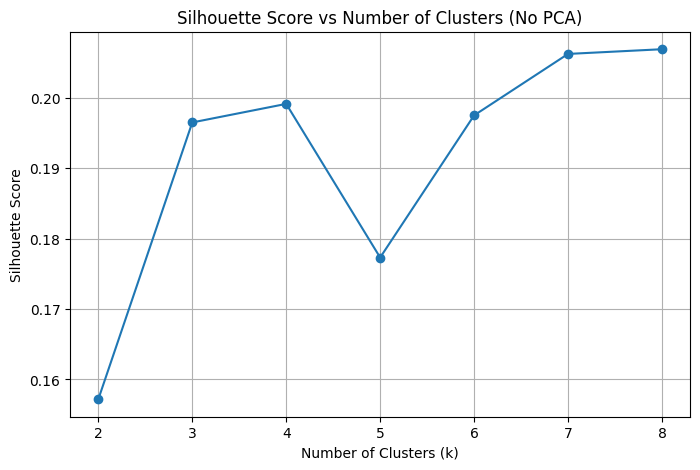

In [65]:
# Calculate Silhouette score --------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Extract only directional SHAP mean + SD SHAP
shap_dir_df = combined_shap_df[
    [col for col in combined_shap_df.columns
     if (col.endswith('_mean_SHAP') or col.endswith('_sd_SHAP')
     ) and '_abs_'not in col]
].copy()

# Check selected columns
print(shap_dir_df.columns.tolist())
print(shap_dir_df.shape)

# Step 2: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(shap_dir_df)

# Step 3: Silhoutte score for n clusters
scores = []
for n_clusters in range(2, 9):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append((n_clusters, score))

    print(f"Clusters={n_clusters}, Silhouette={score:.4f}")


# Convert to DataFrame
dir_df = pd.DataFrame(scores, columns=['Clusters', 'Silhouette'])

# Plot silhouette vs number of clusters
plt.figure(figsize=(8,5))
plt.plot(dir_df['Clusters'], dir_df['Silhouette'], marker='o')
plt.title("Silhouette Score vs Number of Clusters (No PCA)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [66]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# 1. Build co-membership matrix
def build_co_membership(X, n_clusters, n_runs=100):
    """
    Run KMeans with different seeds and build co-membership matrix.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data (e.g. SHAP profiles).
    n_clusters : int
        Number of clusters to use.
    n_runs : int, default=100
        Number of random seeds (runs).

    Returns
    -------
    co_mat : ndarray, shape (n_samples, n_samples)
        Co-membership matrix (proportion of runs i,j in same cluster).
    labels_all : list
        List of cluster label arrays from each run.
    """
    n = X.shape[0]
    co_mat = np.zeros((n, n))
    labels_all = []

    for seed in range(n_runs):
        kmeans = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit(X)
        labels = kmeans.labels_
        labels_all.append(labels)

        for i in range(n):
            for j in range(n):
                if labels[i] == labels[j]:
                    co_mat[i, j] += 1

    co_mat /= n_runs
    return co_mat, labels_all


# 2. Consensus clustering (re-cluster the co-membership matrix)
def consensus_clustering(co_mat, n_clusters):
    """
    Perform average-linkage hierarchical clustering directly on the
    consensus dissimilarity matrix: distance = 1 - co-membership.
    """
    dist_mat = 1 - co_mat

    # Ensure exact symmetry and a zero diagonal
    dist_mat = (dist_mat + dist_mat.T) / 2
    np.fill_diagonal(dist_mat, 0)

    # scipy linkage requires a condensed distance vector
    condensed_dist = squareform(dist_mat, checks=False)

    linkage_matrix = linkage(condensed_dist, method="average")

    labels = fcluster(
        linkage_matrix,
        t=n_clusters,
        criterion="maxclust"
    )

    return labels


# 3. Stability calculation
def compute_stability(co_mat, consensus_labels):
    """
    Compute per-person and per-cluster stability from co-membership matrix.
    """
    n = co_mat.shape[0]
    stability_per_person = []

    for i in range(n):
        cluster = consensus_labels[i]
        members = np.where(consensus_labels == cluster)[0]
        members = members[members != i]

        if len(members) > 0:
            stability = co_mat[i, members].mean()
        else:
            stability = np.nan
        stability_per_person.append(stability)

    stability_per_person = pd.Series(stability_per_person, name="stability")
    stability_per_cluster = pd.DataFrame({
        "cluster": consensus_labels,
        "stability": stability_per_person
    }).groupby("cluster")["stability"].mean()

    return stability_per_person, stability_per_cluster

In [67]:
# --- Stability Analysis (add-on) ---
co_mat, all_labels = build_co_membership(X_scaled, n_clusters=3, n_runs=100)

# Consensus clustering from the co-membership matrix
consensus_labels = consensus_clustering(co_mat, n_clusters=3)

# Compute stability scores
person_stability, cluster_stability = compute_stability(co_mat, consensus_labels)

print("\nCluster-level stability:\n", cluster_stability)
print("\nPer-person stability (first 10 participants):\n", person_stability.head(20))


Cluster-level stability:
 cluster
1    0.996727
2    0.974318
3    0.966920
Name: stability, dtype: float64

Per-person stability (first 10 participants):
 0     0.982174
1     0.982174
2     0.940312
3     0.985625
4     0.998000
5     0.976957
6     0.982174
7     0.985625
8     0.942187
9     0.855000
10    0.976957
11    0.998000
12    0.991000
13    0.982174
14    0.985625
15    0.985625
16    0.982174
17    0.642174
18    0.998000
19    0.985625
Name: stability, dtype: float64


In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def plot_co_membership(
    co_mat,
    consensus_labels,
    title="Co-membership Matrix"
):
    """
    Plot a consensus co-membership matrix, reordered by consensus cluster.

    Participant indices represent plotting positions after reordering,
    not original participant IDs.
    """

    # Use stable sorting so the within-cluster order is reproducible
    order = np.argsort(consensus_labels, kind="stable")

    co_mat_ordered = co_mat[np.ix_(order, order)]
    labels_ordered = consensus_labels[order]

    n = co_mat_ordered.shape[0]

    # Confirm cluster sizes and plotting ranges
    cluster_counts = pd.Series(labels_ordered).value_counts().sort_index()

    print("Cluster sizes:")
    print(cluster_counts)

    start = 1
    for cluster, size in cluster_counts.items():
        end = start + size - 1
        print(
            f"Cluster {cluster}: plotting indices "
            f"{start}–{end} (n={size})"
        )
        start = end + 1

    # Boundaries between clusters
    boundaries = np.where(np.diff(labels_ordered) != 0)[0] + 1

    print("Boundary positions:", boundaries)

    # Plot
    fig, ax = plt.subplots(figsize=(8.5, 7))

    sns.heatmap(
        co_mat_ordered,
        cmap="viridis",
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={
            "label": "Proportion of runs clustered together"
        },
        ax=ax
    )

    # Draw cluster boundaries
    for boundary in boundaries:
        ax.axhline(boundary, color="white", linewidth=1.5)
        ax.axvline(boundary, color="white", linewidth=1.5)

    # Correct tick positions: heatmap cell centers are at i - 0.5
    tick_labels = [1] + list(range(5, n + 1, 5))
    tick_positions = [i - 0.5 for i in tick_labels]

    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)

    ax.set_xticklabels(
        tick_labels,
        fontsize=8,
        rotation=90
    )
    ax.set_yticklabels(
        tick_labels,
        fontsize=8,
        rotation=0
    )

    # Add cluster labels above the matrix
    start_position = 0

    for cluster, size in cluster_counts.items():
        center = start_position + size / 2

        ax.text(
            center,
            -1.4,
            f"Cluster {cluster}\n(n={size})",
            ha="center",
            va="bottom",
            fontsize=9,
            clip_on=False
        )

        start_position += size

    ax.set_title(title, fontsize=12, pad=35)
    ax.set_xlabel("Participant index after cluster-based reordering", fontsize=10)
    ax.set_ylabel("Participant index after cluster-based reordering", fontsize=10)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label(
        "Proportion of runs\nclustered together",
        fontsize=9,
        labelpad=8
    )

    plt.tight_layout()
    plt.show()

In [ ]:
plot_co_membership(co_mat, consensus_labels, title="Co-membership Matrix (Consensus Clustering)")

In [75]:
# Compare with MBI scores----------------------------------------------------------
# Merge mbi_df to coef_matrix
# First, create a DataFrame for consensus clusters from u_ids and consensus_labels
consensus_cluster_df = pd.DataFrame({
    'u_id': combined_shap_df['u_id'],
    'ConsensusCluster': consensus_labels
})

# Now, merge combined_shap_df with consensus_cluster_df, then with mbi_df
# This ensures 'ConsensusCluster' is present in shap_merged_df from the start
shap_merged_df = combined_shap_df.merge(consensus_cluster_df, on='u_id', how='left')
shap_merged_df = shap_merged_df.merge(mbi_df, on='u_id', how='inner')

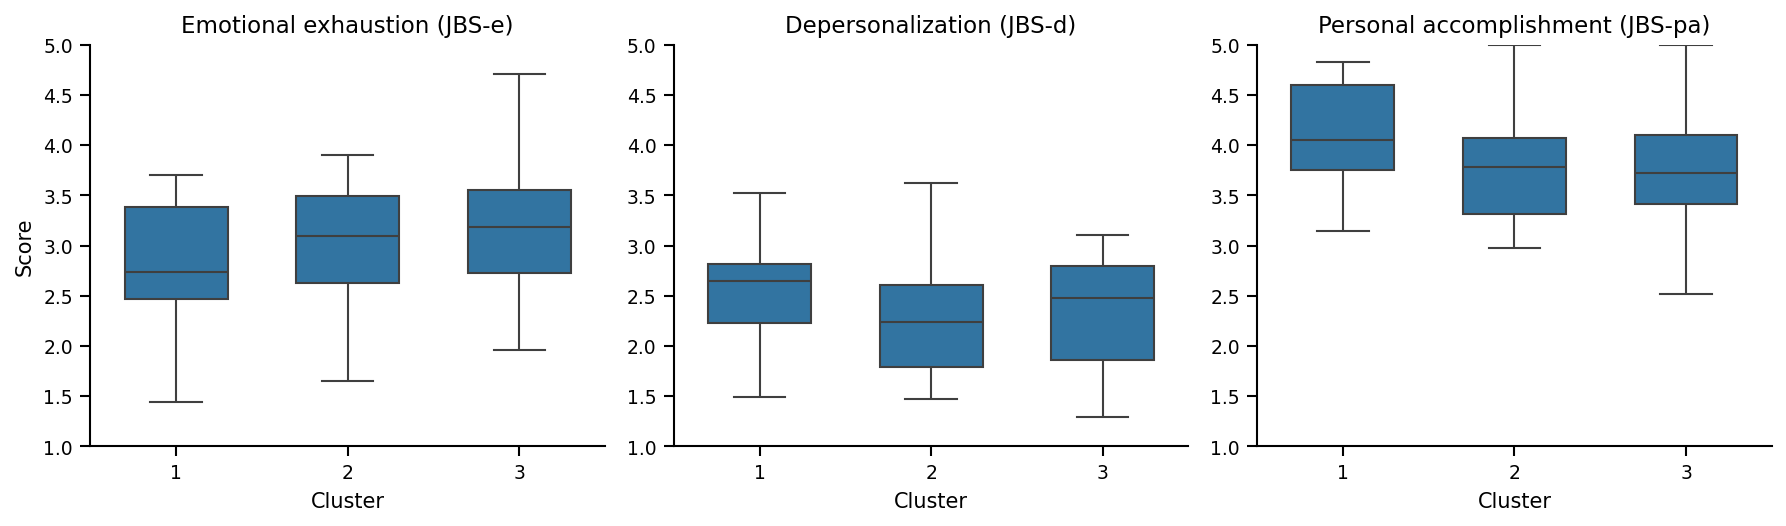

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Merge clusters (same as yours) ---
shap_merged_df = shap_merged_df.copy()
shap_merged_df["ConsensusCluster_merged"] = shap_merged_df["ConsensusCluster"].astype(str)

# Order clusters numerically
cluster_order = sorted(
    shap_merged_df["ConsensusCluster_merged"].unique(),
    key=lambda x: int(x)
)

# Panel definitions: (column, panel title)
panel_specs = [
    ("JBS-e_pre",  "Emotional exhaustion (JBS-e)"),
    ("JBS-d_pre",  "Depersonalization (JBS-d)"),
    ("JBS-pa_pre", "Personal accomplishment (JBS-pa)"),
]

# --- Plot ---
sns.set_context("paper")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), dpi=150)

for ax, (col, panel_title) in zip(axes, panel_specs):
    sns.boxplot(
        data=shap_merged_df,
        x="ConsensusCluster_merged",
        y=col,
        order=cluster_order,
        ax=ax,
        width=0.6,
        linewidth=1,
        showfliers=True
    )

    ax.set_title(panel_title, fontsize=11, pad=6)
    ax.set_xlabel("Cluster", fontsize=10)
    ax.set_ylabel("Score" if ax is axes[0] else "", fontsize=10)

    ax.set_ylim(1,5)

    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig.tight_layout()

plt.show()

In [77]:
import numpy as np
import pandas as pd
from scipy import stats

burnout_vars = [
    "JBS-e_pre",
    "JBS-d_pre",
    "JBS-pa_pre"
]

results = []

for var in burnout_vars:

    df = shap_merged_df[[var, "ConsensusCluster_merged"]].dropna()

    groups = [
        g[var].values
        for _, g in df.groupby("ConsensusCluster_merged")
    ]

    # ANOVA
    F, p = stats.f_oneway(*groups)

    # Effect size (eta squared)
    grand_mean = df[var].mean()

    ss_between = sum(
        len(g) * (g.mean() - grand_mean) ** 2
        for g in groups
    )

    ss_total = np.sum((df[var] - grand_mean) ** 2)

    eta2 = ss_between / ss_total

    results.append({
        "Outcome": var,
        "N": len(df),
        "df1": len(groups) - 1,
        "df2": len(df) - len(groups),
        "F": F,
        "p": p,
        "eta2": eta2
    })

results_df = pd.DataFrame(results)

print(results_df.round(3))

      Outcome   N  df1  df2      F      p   eta2
0   JBS-e_pre  68    2   65  1.200  0.308  0.036
1   JBS-d_pre  68    2   65  0.862  0.427  0.026
2  JBS-pa_pre  68    2   65  1.705  0.190  0.050


# 03_Ordinal Sensitivity.ipynb


In [78]:
# ============================================================
# Ordinal sensitivity analysis: N-of-1 only
# ============================================================

from itertools import combinations
import random, os
import numpy as np
import pandas as pd

from tqdm import tqdm
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    mean_absolute_error
)
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
from statsmodels.miscmodels.ordinal_model import OrderedModel

# -----------------------------
# 0. Seed
# -----------------------------

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(42)



In [79]:
# -----------------------------
# 1. Create ordinal target
# -----------------------------

def add_ordinal_target(
    df,
    target_var="wb_morning",
    ordinal_target="wb_morning_ord",
    n_bins=3
):
    df = df.copy()

    df[ordinal_target] = pd.qcut(
        df[target_var],
        q=n_bins,
        labels=False,
        duplicates="drop"
    )

    df = df.dropna(subset=[ordinal_target])
    df[ordinal_target] = df[ordinal_target].astype(int)

    return df


# -----------------------------
# 2. Rolling-origin splits
# -----------------------------

def generate_rolling_origin_splits(n_days=35, n_splits=5):
    splits = []

    for i in range(n_splits):
        train_end = n_days - (i + 3)
        test_start = n_days - (i + 2)

        train_idx = list(range(train_end))
        test_idx = list(range(test_start, n_days))

        if len(train_idx) > 0 and len(test_idx) > 0:
            splits.append((train_idx, test_idx))

    return splits


In [80]:
# -----------------------------
# 3. Metrics
# -----------------------------

def ordinal_metrics(y_true, y_pred):
    return {
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "quadratic_kappa": cohen_kappa_score(
            y_true,
            y_pred,
            weights="quadratic"
        ),
        "ordinal_MAE": mean_absolute_error(y_true, y_pred)
    }


# -----------------------------
# 4. Ordered logistic helper
# -----------------------------
def fit_predict_ordered_logit(X_train, y_train, X_test, verbose=True):
    """
    Ordered logistic regression with class re-mapping.
    Important because some outer folds may contain only classes like [1, 2],
    not [0, 1, 2].
    """

    if y_train.nunique() < 2:
        return None

    # Map observed training classes to consecutive 0, 1, ...
    train_classes = np.sort(y_train.unique())
    class_to_encoded = {cls: i for i, cls in enumerate(train_classes)}
    encoded_to_class = {i: cls for cls, i in class_to_encoded.items()}

    y_train_encoded = y_train.map(class_to_encoded).astype(int)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    try:
        model = OrderedModel(
            y_train_encoded,
            X_train_scaled,
            distr="logit"
        )

        res = model.fit(method="bfgs", disp=False)
        pred_probs = res.model.predict(res.params, exog=X_test_scaled)

        y_pred_encoded = np.argmax(pred_probs, axis=1)

        y_pred = np.array([
            encoded_to_class[p] for p in y_pred_encoded
        ])

        return y_pred

    except Exception as e:
        if verbose:
            print(f"Ordered Logit failed: {e}")
            print("y_train classes:", sorted(y_train.unique()))
            print("X_train shape:", X_train.shape)
        return None

In [81]:
# -----------------------------
# 5. Statistical model comparison
# -----------------------------

def compare_ordinal_models_statistically(all_model_results, alpha=0.05):
    """
    Compare ordinal models using fold-level ordinal MAE.
    Lower ordinal MAE is better.
    """

    model_names = list(all_model_results.keys())

    fold_scores_list = [
        all_model_results[m]["fold_ordinal_MAE"]
        for m in model_names
        if len(all_model_results[m]["fold_ordinal_MAE"]) > 0
    ]

    model_names = [
        m for m in model_names
        if len(all_model_results[m]["fold_ordinal_MAE"]) > 0
    ]

    if len(model_names) == 0:
        raise ValueError("No valid model results available.")

    if len(model_names) == 1:
        return model_names, np.nan, {}

    if len(model_names) == 2:
        medians = {
            m: np.nanmedian(all_model_results[m]["fold_ordinal_MAE"])
            for m in model_names
        }

        best_model = min(medians, key=medians.get)

        m1, m2 = model_names
        min_len = min(
            len(all_model_results[m1]["fold_ordinal_MAE"]),
            len(all_model_results[m2]["fold_ordinal_MAE"])
        )

        if min_len >= 2:
            x = np.array(all_model_results[m1]["fold_ordinal_MAE"][:min_len])
            y = np.array(all_model_results[m2]["fold_ordinal_MAE"][:min_len])

            try:
                _, p = wilcoxon(x, y)
            except Exception:
                p = np.nan

            pairwise_p_adjusted = {(m1, m2): p}
        else:
            pairwise_p_adjusted = {}

        return [best_model], np.nan, pairwise_p_adjusted

    min_len = min(len(f) for f in fold_scores_list)

    if min_len < 2:
        medians = {
            m: np.nanmedian(all_model_results[m]["fold_ordinal_MAE"])
            for m in model_names
        }
        best_model = min(medians, key=medians.get)
        return [best_model], np.nan, {}

    fold_scores_trimmed = [
        all_model_results[m]["fold_ordinal_MAE"][:min_len]
        for m in model_names
    ]

    stat, friedman_p = friedmanchisquare(*fold_scores_trimmed)
    print(f"Friedman Test Statistic: {stat:.3f}, p: {friedman_p:.4f}")

    medians = {
        m: np.nanmedian(all_model_results[m]["fold_ordinal_MAE"])
        for m in model_names
    }

    best_model = min(medians, key=medians.get)

    if friedman_p >= alpha:
        return [best_model], friedman_p, {}

    pairs = list(combinations(model_names, 2))
    p_values = []

    for m1, m2 in pairs:
        x = np.array(all_model_results[m1]["fold_ordinal_MAE"][:min_len])
        y = np.array(all_model_results[m2]["fold_ordinal_MAE"][:min_len])

        try:
            _, p = wilcoxon(x, y)
        except Exception:
            p = 1.0

        p_values.append(p)

    _, pvals_corrected, _, _ = multipletests(
        p_values,
        alpha=alpha,
        method="holm"
    )

    pairwise_p_adjusted = {
        pair: pval for pair, pval in zip(pairs, pvals_corrected)
    }

    print("Pairwise Holm-adjusted p-values:")
    for pair, p in pairwise_p_adjusted.items():
        print(f"{pair[0]} vs {pair[1]}: p={p:.4f}")

    top_models = [best_model]

    for m in model_names:
        if m == best_model:
            continue

        key = (
            (best_model, m)
            if (best_model, m) in pairwise_p_adjusted
            else (m, best_model)
        )

        if pairwise_p_adjusted.get(key, 1.0) >= alpha:
            top_models.append(m)

    return top_models, friedman_p, pairwise_p_adjusted


In [82]:
# -----------------------------
# 5b. Cumulative ordinal RF/XGB helper
# -----------------------------

class CumulativeOrdinalClassifier(BaseEstimator, ClassifierMixin):
    """
    Ordinal classifier based on cumulative binary models.

    For classes 0, 1, 2, fits:
        P(Y > 0)
        P(Y > 1)

    The final ordinal class is determined from these cumulative
    probabilities.
    """

    def __init__(
        self,
        base_estimator,
        classes=None,
        prediction_method="median"
    ):
        self.base_estimator = base_estimator
        self.classes = classes
        self.prediction_method = prediction_method

    def fit(self, X, y):
        y = np.asarray(y)

        if self.classes is None:
            self.classes_ = np.sort(np.unique(y))
        else:
            self.classes_ = np.asarray(self.classes)

        if len(self.classes_) < 2:
            raise ValueError(
                "At least two ordered classes are required."
            )

        self.thresholds_ = self.classes_[:-1]
        self.models_ = []
        self.constant_probabilities_ = []

        for threshold in self.thresholds_:

            y_binary = (y > threshold).astype(int)
            unique_binary = np.unique(y_binary)

            # Some small training folds may contain observations
            # on only one side of a threshold.
            if len(unique_binary) == 1:

                self.models_.append(None)

                self.constant_probabilities_.append(
                    float(unique_binary[0])
                )

            else:

                model = clone(self.base_estimator)
                model.fit(X, y_binary)

                self.models_.append(model)
                self.constant_probabilities_.append(None)

        return self

    def _predict_cumulative_probabilities(self, X):

        cumulative_probabilities = []

        for model, constant_probability in zip(
            self.models_,
            self.constant_probabilities_
        ):

            if model is None:

                probability = np.full(
                    len(X),
                    constant_probability,
                    dtype=float
                )

            else:

                probability = model.predict_proba(X)[:, 1]

            cumulative_probabilities.append(probability)

        cumulative_probabilities = np.column_stack(
            cumulative_probabilities
        )

        # Enforce:
        # P(Y > 0) >= P(Y > 1) >= ...
        cumulative_probabilities = np.minimum.accumulate(
            cumulative_probabilities,
            axis=1
        )

        return cumulative_probabilities

    def predict_proba(self, X):

        cumulative_probabilities = (
            self._predict_cumulative_probabilities(X)
        )

        n_samples = len(X)
        n_classes = len(self.classes_)

        class_probabilities = np.zeros(
            (n_samples, n_classes),
            dtype=float
        )

        # Lowest category
        class_probabilities[:, 0] = (
            1.0 - cumulative_probabilities[:, 0]
        )

        # Intermediate categories
        for class_index in range(1, n_classes - 1):

            class_probabilities[:, class_index] = (
                cumulative_probabilities[:, class_index - 1]
                - cumulative_probabilities[:, class_index]
            )

        # Highest category
        class_probabilities[:, -1] = (
            cumulative_probabilities[:, -1]
        )

        class_probabilities = np.clip(
            class_probabilities,
            0.0,
            1.0
        )

        row_sums = class_probabilities.sum(
            axis=1,
            keepdims=True
        )

        row_sums[row_sums == 0] = 1.0

        return class_probabilities / row_sums

    def predict(self, X):

        cumulative_probabilities = (
            self._predict_cumulative_probabilities(X)
        )

        if self.prediction_method == "median":

            # Number of thresholds crossed determines class.
            class_indices = np.sum(
                cumulative_probabilities >= 0.5,
                axis=1
            )

        elif self.prediction_method == "expected":

            class_probabilities = self.predict_proba(X)

            expected_index = (
                class_probabilities
                * np.arange(len(self.classes_))
            ).sum(axis=1)

            class_indices = np.rint(
                expected_index
            ).astype(int)

            class_indices = np.clip(
                class_indices,
                0,
                len(self.classes_) - 1
            )

        else:
            raise ValueError(
                "prediction_method must be "
                "'median' or 'expected'."
            )

        return self.classes_[class_indices]


def build_ordinal_tree_model(
    model_name,
    params,
    ordered_classes,
    random_state
):
    """
    Build an ordinal random forest or ordinal XGBoost model.
    """

    if model_name == "Ordinal_RF":

        base_estimator = RandomForestClassifier(
            random_state=random_state,
            class_weight="balanced",
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            n_jobs=-1
        )

    elif model_name == "Ordinal_XGB":

        base_estimator = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=random_state,
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=1.0,
            colsample_bytree=1.0,
            tree_method="hist",
            n_jobs=-1
        )

    else:
        raise ValueError(
            f"Unknown model name: {model_name}"
        )

    return CumulativeOrdinalClassifier(
        base_estimator=base_estimator,
        classes=ordered_classes,
        prediction_method="median"
    )

In [83]:
# -----------------------------
# 6. Proper nested CV per participant
# -----------------------------

def nested_cv_time_aware_with_ordinal_models(
    X,
    y,
    inner_splits=4,
    n_splits=5,
    n_repeats=4,
    u_id=None
):

    # --------------------------------------------------------
    # Candidate ordinal models and hyperparameter grids
    # --------------------------------------------------------

    model_dict = {
        "Ordinal_Logit": {
            "params": {}
        },

        "Ordinal_RF": {
            "params": {
                "n_estimators": [50, 100],
                "max_depth": [3, 5]
            }
        },

        "Ordinal_XGB": {
            "params": {
                "n_estimators": [50, 100],
                "max_depth": [3, 5],
                "learning_rate": [0.05, 0.1]
            }
        }
    }

    all_model_results = {}

    # --------------------------------------------------------
    # Remove rows containing missing predictor or outcome data
    # --------------------------------------------------------

    df_tmp = pd.concat([X, y], axis=1).dropna()

    X = df_tmp[X.columns].copy()
    y = df_tmp[y.name].astype(int).copy()

    n_days = len(X)

    # Keep the intended three-category ordinal scale even when
    # a training fold does not contain all three categories.
    ordered_classes = np.array([0, 1, 2])

    all_classes = set(ordered_classes)

    # --------------------------------------------------------
    # Generate outer rolling-origin splits
    # --------------------------------------------------------

    outer_splits = generate_rolling_origin_splits(
        n_days=n_days,
        n_splits=n_splits
    )

    diagnostics = []
    prediction_rows = []

    # ========================================================
    # Loop through candidate models
    # ========================================================

    for model_name, model_info in model_dict.items():

        param_list = list(
            ParameterGrid(model_info["params"])
        )

        if len(param_list) == 0:
            param_list = [{}]

        fold_macro_f1 = []
        fold_bal_acc = []
        fold_kappa = []
        fold_ord_mae = []

        best_model_instance = None
        best_model_score = np.inf

        # ====================================================
        # Outer rolling-origin cross-validation
        # ====================================================

        for fold_idx, (train_idx, test_idx) in enumerate(
            outer_splits
        ):

            X_train_outer = X.iloc[train_idx]
            X_test_outer = X.iloc[test_idx]

            y_train_outer = y.iloc[train_idx]
            y_test_outer = y.iloc[test_idx]

            # ------------------------------------------------
            # Fold diagnostics
            # ------------------------------------------------

            train_classes = set(
                y_train_outer.unique()
            )

            test_classes = set(
                y_test_outer.unique()
            )

            diag_row = {
                "u_id": u_id,
                "fold": fold_idx,
                "model": model_name,
                "n_train": len(y_train_outer),
                "n_test": len(y_test_outer),
                "train_classes": sorted(train_classes),
                "test_classes": sorted(test_classes),
                "missing_train_classes": sorted(
                    all_classes - train_classes
                ),
                "missing_test_classes": sorted(
                    all_classes - test_classes
                ),
                "n_train_classes": (
                    y_train_outer.nunique()
                ),
                "n_test_classes": (
                    y_test_outer.nunique()
                )
            }

            for class_value in sorted(all_classes):

                diag_row[
                    f"train_class_{class_value}_n"
                ] = int(
                    (y_train_outer == class_value).sum()
                )

                diag_row[
                    f"test_class_{class_value}_n"
                ] = int(
                    (y_test_outer == class_value).sum()
                )

            diagnostics.append(diag_row)

            # A model cannot be trained if the outer training
            # set contains only one outcome category.
            if y_train_outer.nunique() < 2:
                continue

            # =================================================
            # Ordinal logistic regression
            # No hyperparameter tuning
            # =================================================

            if model_name == "Ordinal_Logit":

                y_pred = fit_predict_ordered_logit(
                    X_train_outer,
                    y_train_outer,
                    X_test_outer
                )

                if y_pred is None:
                    continue

                y_pred = np.asarray(
                    y_pred
                ).astype(int)

                metrics = ordinal_metrics(
                    y_test_outer,
                    y_pred
                )

                prediction_rows.extend(
                    pd.DataFrame({
                        "u_id": u_id,
                        "fold": fold_idx,
                        "rep": 0,
                        "model": model_name,
                        "y_true": y_test_outer.values,
                        "y_pred": y_pred
                    }).to_dict("records")
                )

                fold_macro_f1.append(
                    metrics["macro_f1"]
                )

                fold_bal_acc.append(
                    metrics["balanced_accuracy"]
                )

                fold_kappa.append(
                    metrics["quadratic_kappa"]
                )

                fold_ord_mae.append(
                    metrics["ordinal_MAE"]
                )

                if (
                    metrics["ordinal_MAE"]
                    < best_model_score
                ):
                    best_model_score = (
                        metrics["ordinal_MAE"]
                    )

                    # fit_predict_ordered_logit currently returns
                    # predictions rather than the fitted model.
                    best_model_instance = None

                continue

            # =================================================
            # Inner time-series CV for ordinal RF and XGB
            # =================================================

            best_params = None
            best_inner_score = np.inf

            max_inner_splits = min(
                inner_splits,
                len(X_train_outer) - 1
            )

            if max_inner_splits < 2:
                continue

            inner_cv = TimeSeriesSplit(
                n_splits=max_inner_splits
            )

            # ------------------------------------------------
            # Hyperparameter search
            # ------------------------------------------------

            for params in param_list:

                inner_maes = []

                for (
                    inner_train_idx,
                    inner_val_idx
                ) in inner_cv.split(X_train_outer):

                    X_inner_train = X_train_outer.iloc[
                        inner_train_idx
                    ]

                    X_inner_val = X_train_outer.iloc[
                        inner_val_idx
                    ]

                    y_inner_train = y_train_outer.iloc[
                        inner_train_idx
                    ]

                    y_inner_val = y_train_outer.iloc[
                        inner_val_idx
                    ]

                    # At least two observed categories are needed.
                    if y_inner_train.nunique() < 2:
                        continue

                    try:
                        model = build_ordinal_tree_model(
                            model_name=model_name,
                            params=params,
                            ordered_classes=ordered_classes,
                            random_state=42
                        )

                        model.fit(
                            X_inner_train,
                            y_inner_train
                        )

                        y_inner_pred = model.predict(
                            X_inner_val
                        )

                        y_inner_pred = np.asarray(
                            y_inner_pred
                        ).astype(int)

                        inner_metrics = ordinal_metrics(
                            y_inner_val,
                            y_inner_pred
                        )

                        inner_maes.append(
                            inner_metrics["ordinal_MAE"]
                        )

                    except Exception as e:

                        print(
                            f"Inner {model_name} failed "
                            f"for user {u_id}, "
                            f"outer fold {fold_idx}: {e}"
                        )

                        continue

                if len(inner_maes) == 0:
                    continue

                mean_inner_mae = np.mean(
                    inner_maes
                )

                if mean_inner_mae < best_inner_score:

                    best_inner_score = mean_inner_mae
                    best_params = params.copy()

            if best_params is None:
                continue

            # =================================================
            # Refit best ordinal RF/XGB on outer training data
            # =================================================

            for rep in range(n_repeats):

                current_seed = (
                    42
                    + rep
                    + fold_idx * 100
                )

                try:
                    final_model = build_ordinal_tree_model(
                        model_name=model_name,
                        params=best_params,
                        ordered_classes=ordered_classes,
                        random_state=current_seed
                    )

                    final_model.fit(
                        X_train_outer,
                        y_train_outer
                    )

                    y_pred = final_model.predict(
                        X_test_outer
                    )

                    y_pred = np.asarray(
                        y_pred
                    ).astype(int)

                    metrics = ordinal_metrics(
                        y_test_outer,
                        y_pred
                    )

                    prediction_rows.extend(
                        pd.DataFrame({
                            "u_id": u_id,
                            "fold": fold_idx,
                            "rep": rep,
                            "model": model_name,
                            "y_true": y_test_outer.values,
                            "y_pred": y_pred
                        }).to_dict("records")
                    )

                    fold_macro_f1.append(
                        metrics["macro_f1"]
                    )

                    fold_bal_acc.append(
                        metrics["balanced_accuracy"]
                    )

                    fold_kappa.append(
                        metrics["quadratic_kappa"]
                    )

                    fold_ord_mae.append(
                        metrics["ordinal_MAE"]
                    )

                    if (
                        metrics["ordinal_MAE"]
                        < best_model_score
                    ):
                        best_model_score = (
                            metrics["ordinal_MAE"]
                        )

                        best_model_instance = (
                            final_model
                        )

                except Exception as e:

                    print(
                        f"{model_name} failed "
                        f"for user {u_id}, "
                        f"fold {fold_idx}, "
                        f"rep {rep}: {e}"
                    )

                    continue

        # ====================================================
        # Store aggregate performance for this model
        # ====================================================

        all_model_results[model_name] = {
            "macro_f1": (
                np.mean(fold_macro_f1)
                if len(fold_macro_f1) > 0
                else np.nan
            ),

            "balanced_accuracy": (
                np.mean(fold_bal_acc)
                if len(fold_bal_acc) > 0
                else np.nan
            ),

            "quadratic_kappa": (
                np.mean(fold_kappa)
                if len(fold_kappa) > 0
                else np.nan
            ),

            "ordinal_MAE": (
                np.mean(fold_ord_mae)
                if len(fold_ord_mae) > 0
                else np.nan
            ),

            "fold_macro_f1": fold_macro_f1,
            "fold_balanced_accuracy": fold_bal_acc,
            "fold_quadratic_kappa": fold_kappa,
            "fold_ordinal_MAE": fold_ord_mae,
            "best_estimator": best_model_instance
        }

    # ========================================================
    # Select the participant-specific best ordinal model
    # ========================================================

    valid_results = {
        model_name: model_results
        for model_name, model_results
        in all_model_results.items()
        if len(
            model_results["fold_ordinal_MAE"]
        ) > 0
    }

    if len(valid_results) == 0:

        return {
            "all_model_results": all_model_results,
            "best_model_name": None,
            "best_model_object": None,

            "best_metrics": {
                "macro_f1": np.nan,
                "balanced_accuracy": np.nan,
                "quadratic_kappa": np.nan,
                "ordinal_MAE": np.nan
            },

            "friedman_p": np.nan,
            "pairwise_p_adjusted": {},

            "diagnostics": pd.DataFrame(
                diagnostics
            ),

            "predictions": pd.DataFrame(
                prediction_rows
            )
        }

   # ========================================================
    # Select the participant-specific best ordinal model
    # based solely on mean outer-CV ordinal MAE
    # ========================================================

    model_mean_mae = {
        model_name: model_results["ordinal_MAE"]
        for model_name, model_results in valid_results.items()
        if np.isfinite(model_results["ordinal_MAE"])
    }

    if len(model_mean_mae) == 0:

        return {
            "all_model_results": all_model_results,
            "best_model_name": None,
            "best_model_object": None,

            "best_metrics": {
                "macro_f1": np.nan,
                "balanced_accuracy": np.nan,
                "quadratic_kappa": np.nan,
                "ordinal_MAE": np.nan
            },

            "diagnostics": pd.DataFrame(diagnostics),
            "predictions": pd.DataFrame(prediction_rows)
        }

    best_model_name = min(
        model_mean_mae,
        key=model_mean_mae.get
    )

    best_model_object = valid_results[
        best_model_name
    ]["best_estimator"]

    best_metrics = {
        "macro_f1": valid_results[
            best_model_name
        ]["macro_f1"],

        "balanced_accuracy": valid_results[
            best_model_name
        ]["balanced_accuracy"],

        "quadratic_kappa": valid_results[
            best_model_name
        ]["quadratic_kappa"],

        "ordinal_MAE": valid_results[
            best_model_name
        ]["ordinal_MAE"]
    }

    print(f"\n=== User {u_id} ===")
    print(
        "Mean outer-CV ordinal MAE by model:",
        {
            model: round(score, 4)
            for model, score in model_mean_mae.items()
        }
    )
    print(
        "Best ordinal model selected: "
        f"{best_model_name}"
    )

    return {
        "all_model_results": all_model_results,
        "best_model_name": best_model_name,
        "best_model_object": best_model_object,
        "best_metrics": best_metrics,
        "diagnostics": pd.DataFrame(diagnostics),
        "predictions": pd.DataFrame(prediction_rows)
    }


    best_model_object = valid_results[
        best_model_name
    ]["best_estimator"]

    best_metrics = {
        "macro_f1": valid_results[
            best_model_name
        ]["macro_f1"],

        "balanced_accuracy": valid_results[
            best_model_name
        ]["balanced_accuracy"],

        "quadratic_kappa": valid_results[
            best_model_name
        ]["quadratic_kappa"],

        "ordinal_MAE": valid_results[
            best_model_name
        ]["ordinal_MAE"]
    }

    print(f"\n=== User {u_id} ===")

    print(
        "Best ordinal model selected: "
        f"{best_model_name}"
    )

    return {
        "all_model_results": all_model_results,
        "best_model_name": best_model_name,
        "best_model_object": best_model_object,
        "best_metrics": best_metrics,
        "friedman_p": friedman_p,
        "pairwise_p_adjusted": pairwise_p_adjusted,

        "diagnostics": pd.DataFrame(
            diagnostics
        ),

        "predictions": pd.DataFrame(
            prediction_rows
        )
    }

In [84]:
# -----------------------------
# 7. Run across all participants
# -----------------------------

def nested_cv_time_aware_per_user_ordinal(
    dataframe,
    predictors,
    target_val,
    ordinal_target="wb_morning_ord",
    inner_splits=4,
    n_bins=3
):

    df_ord = add_ordinal_target(
        dataframe,
        target_var=target_val,
        ordinal_target=ordinal_target,
        n_bins=n_bins
    )

    best_models = []
    all_diagnostics = []
    all_predictions = []

    for u_id, group in tqdm(
        df_ord.groupby("u_id"),
        desc="Running ordinal per participant"
    ):

        group_clean = group.dropna(subset=[ordinal_target] + predictors)
        group_clean = group_clean.sort_values(by="date").reset_index(drop=True)

        if len(group_clean) < 10:
            continue

        if group_clean[ordinal_target].nunique() < 2:
            continue

        X = group_clean[predictors].reset_index(drop=True)
        y = group_clean[ordinal_target].reset_index(drop=True)

        result = nested_cv_time_aware_with_ordinal_models(
            X,
            y,
            inner_splits=inner_splits,
            u_id=u_id
        )

        all_diagnostics.append(result["diagnostics"])

        if "predictions" in result:
            all_predictions.append(result["predictions"])


        best_model_name = result["best_model_name"]
        best_metrics = result["best_metrics"]
        all_model_results = result["all_model_results"]

        best_models.append({
            "u_id": u_id,
            "model": best_model_name,

            "macro_f1": best_metrics["macro_f1"],
            "balanced_accuracy": best_metrics["balanced_accuracy"],
            "quadratic_kappa": best_metrics["quadratic_kappa"],
            "ordinal_MAE": best_metrics["ordinal_MAE"],

            "Ordinal_Logit_macro_f1": (
                all_model_results
                .get("Ordinal_Logit", {})
                .get("macro_f1", np.nan)
            ),

            "Ordinal_RF_macro_f1": (
                all_model_results
                .get("Ordinal_RF", {})
                .get("macro_f1", np.nan)
            ),

            "Ordinal_XGB_macro_f1": (
                all_model_results
                .get("Ordinal_XGB", {})
                .get("macro_f1", np.nan)
            ),

            "Ordinal_Logit_balanced_accuracy": (
                all_model_results
                .get("Ordinal_Logit", {})
                .get("balanced_accuracy", np.nan)
            ),

            "Ordinal_RF_balanced_accuracy": (
                all_model_results
                .get("Ordinal_RF", {})
                .get("balanced_accuracy", np.nan)
            ),

            "Ordinal_XGB_balanced_accuracy": (
                all_model_results
                .get("Ordinal_XGB", {})
                .get("balanced_accuracy", np.nan)
            ),

            "Ordinal_Logit_quadratic_kappa": (
                all_model_results
                .get("Ordinal_Logit", {})
                .get("quadratic_kappa", np.nan)
            ),

            "Ordinal_RF_quadratic_kappa": (
                all_model_results
                .get("Ordinal_RF", {})
                .get("quadratic_kappa", np.nan)
            ),

            "Ordinal_XGB_quadratic_kappa": (
                all_model_results
                .get("Ordinal_XGB", {})
                .get("quadratic_kappa", np.nan)
            ),

            "Ordinal_Logit_ordinal_MAE": (
                all_model_results
                .get("Ordinal_Logit", {})
                .get("ordinal_MAE", np.nan)
            ),

            "Ordinal_RF_ordinal_MAE": (
                all_model_results
                .get("Ordinal_RF", {})
                .get("ordinal_MAE", np.nan)
            ),

            "Ordinal_XGB_ordinal_MAE": (
                all_model_results
                .get("Ordinal_XGB", {})
                .get("ordinal_MAE", np.nan)
            )
        })

    best_models_df = pd.DataFrame(best_models).set_index("u_id")

    if len(all_diagnostics) > 0:
        diagnostics_df = pd.concat(all_diagnostics, ignore_index=True)
    else:
        diagnostics_df = pd.DataFrame()

    if len(all_predictions) > 0:
        predictions_df = pd.concat(all_predictions, ignore_index=True)
    else:
        predictions_df = pd.DataFrame()

    return best_models_df, diagnostics_df, predictions_df

In [85]:
predictors = [
    "totalTimeInBed",
    "heartrate_lag1",
    "inpatient_lag1",
    "steps_lag1",
    "workday"
]

target_var = "wb_morning"



best_models_df, diagnostics_df, predictions_df = nested_cv_time_aware_per_user_ordinal(
    dataframe=model_df_modeling,
    predictors=predictors,
    target_val=target_var,
    ordinal_target="wb_morning_ord",
    n_bins=3
)

display(best_models_df.head())

Running ordinal per participant:   0%|          | 0/68 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes 


=== User D001 ===
Mean outer-CV ordinal MAE by model: {'Ordinal_Logit': np.float64(1.1333), 'Ordinal_RF': np.float64(0.6308), 'Ordinal_XGB': np.float64(0.58)}
Best ordinal model selected: Ordinal_XGB


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: U


=== User D002 ===
Mean outer-CV ordinal MAE by model: {'Ordinal_Logit': np.float64(0.8933), 'Ordinal_RF': np.float64(0.3083), 'Ordinal_XGB': np.float64(0.3633)}
Best ordinal model selected: Ordinal_RF


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: 

...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: 


=== User D067 ===
Mean outer-CV ordinal MAE by model: {'Ordinal_Logit': np.float64(0.23), 'Ordinal_RF': np.float64(0.3683), 'Ordinal_XGB': np.float64(0.4467)}
Best ordinal model selected: Ordinal_Logit


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics


=== User D068 ===
Mean outer-CV ordinal MAE by model: {'Ordinal_Logit': np.float64(0.6533), 'Ordinal_RF': np.float64(0.5917), 'Ordinal_XGB': np.float64(0.6167)}
Best ordinal model selected: Ordinal_RF


,model,macro_f1,balanced_accuracy,quadratic_kappa,ordinal_MAE,Ordinal_Logit_macro_f1,Ordinal_RF_macro_f1,Ordinal_XGB_macro_f1,Ordinal_Logit_balanced_accuracy,Ordinal_RF_balanced_accuracy,Ordinal_XGB_balanced_accuracy,Ordinal_Logit_quadratic_kappa,Ordinal_RF_quadratic_kappa,Ordinal_XGB_quadratic_kappa,Ordinal_Logit_ordinal_MAE,Ordinal_RF_ordinal_MAE,Ordinal_XGB_ordinal_MAE
u_id,,,,,,,,,,,,,,,,,
D001,Ordinal_XGB,0.372222,0.372222,0.029412,0.580000,0.111111,0.334722,0.372222,0.200000,0.365278,0.372222,-0.158476,0.097961,0.029412,1.133333,0.630833,0.580000
D002,Ordinal_RF,0.683968,0.741667,NaN,0.308333,0.203333,0.683968,0.684444,0.333333,0.741667,0.733333,0.069565,NaN,NaN,0.893333,0.308333,0.363333
D003,Ordinal_XGB,0.404444,0.516667,-0.032251,0.630000,0.395873,0.304722,0.404444,0.500000,0.375000,0.516667,NaN,-0.252219,-0.032251,0.643333,0.962500,0.630000
D004,Ordinal_XGB,0.648889,0.771667,0.437815,0.303333,0.477143,0.538690,0.648889,0.648333,0.682917,0.771667,0.179893,0.309858,0.437815,0.486667,0.427500,0.303333
D005,Ordinal_RF,0.300000,0.533333,0.088311,0.705833,0.322222,0.300000,0.293333,0.566667,0.533333,0.533333,-0.021452,0.088311,-0.069481,0.916667,0.705833,0.950000


# 04_Construct_validity

In [1]:
# Install R
!apt-get update -qq
!apt-get install -y r-base -qq

# Install required R packages
!R -e 'install.packages(c("lavaan", "readxl", "dplyr"), repos="https://cloud.r-project.org")'

# Install Python-R interface
!pip install -q rpy2

# Load the R magic
%load_ext rpy2.ipython

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../r-base-core_4.6.1-1.2204.1_amd64.deb ...
Unpacking r-base-core (4.6.1-1.2204.1) over (4.6.0-4.2204.0) ...
Preparing to unpack .../r-base_4.6.1-1.2204.1_all.deb ...
Unpacking r-base (4.6.1-1.2204.1) over (4.6.0-4.2204.0) ...
Preparing to unpack .../r-recommended_4.6.1-1.2204.1_all.deb ...
Unpacking r-recommended (4.6.1-1.2204.1) over (4.6.0-4.2204.0) ...
Setting up r-base-core (4.6.1-1.2204.1) ...
Installing new version of config file /etc/R/Makeconf ...
Setting up r-recommended (4.6.1-1.2204.1) ...
Setting up r-base (4.6.1-1.2204.1) ...
Processing triggers for hicolor-icon-theme (0.17-2) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for mailcap (3.70+nmu1ubuntu1) ...

R version 4.6

In [4]:
%%R

library(readr)
library(lavaan)
library(dplyr)

df <- read_csv(
    "/content/drive/MyDrive/dummy_two_factor_data.csv"
)

Rows: 70 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (23): u_id, alertness_morning_mean, happiness_morning_mean, energymornin...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


This is lavaan 0.7-2
lavaan is FREE software! Please report any bugs.

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



In [6]:
# Define the CFA model
%%R

wellbeing_items <- c(
  "alertness_morning_mean",
  "happiness_morning_mean",
  "energymorning_mean",
  "healthmorning_mean",
  "relaxmorning_mean"
)

jbs_items <- paste0("Q", 1:17)

cfa_df <- df %>%
  select(
    u_id,
    all_of(wellbeing_items),
    all_of(jbs_items)
  )

model_cfa <- '

  # Morning well-being
  Wellbeing =~
      alertness_morning_mean
    + happiness_morning_mean
    + energymorning_mean
    + healthmorning_mean
    + relaxmorning_mean

  # Japanese Burnout Scale:
  # Emotional exhaustion
  EmotionalExhaustion =~
      Q1
    + Q7
    + Q8
    + Q12
    + Q16

  # Depersonalization
  Depersonalization =~
      Q3
    + Q5
    + Q6
    + Q10
    + Q11
    + Q14

  # Decline in personal accomplishment
  PersonalAccomplishmentDecline =~
      Q2
    + Q4
    + Q9
    + Q13
    + Q15
    + Q17

'

# ------------------------------------------------------------
# Reverse-score personal accomplishment items
# Raw Q items: higher = greater personal accomplishment
# After reversal: higher = greater decline in personal accomplishment
# ------------------------------------------------------------

pa_items <- c(
  "Q2",
  "Q4",
  "Q9",
  "Q13",
  "Q15",
  "Q17"
)

cfa_df <- cfa_df %>%
  mutate(
    across(
      all_of(pa_items),
      ~ 6 - .
    )
  )

# ------------------------------------------------------------
# Treat JBS responses as ordinal
# ------------------------------------------------------------

cfa_df[jbs_items] <- lapply(
  cfa_df[jbs_items],
  ordered
)

# ------------------------------------------------------------
# Fit CFA
# ------------------------------------------------------------

fit_cfa <- cfa(
  model = model_cfa,
  data = cfa_df,
  ordered = jbs_items,
  estimator = "WLSMV",
  std.lv = TRUE,
  missing = "pairwise"
)


# Display the model results

summary(
  fit_cfa,
  standardized = TRUE,
  fit.measures = TRUE,
  rsquare = TRUE
)

lavaan 0.7-2 ended normally after 88 iterations

  Estimator                                       DWLS
  Optimization method                           NLMINB
  Number of model parameters                       101

  Number of observations                            70
  Number of missing patterns                         1

Model Test User Model:
                                              Standard      Scaled
  Test Statistic                               196.311     209.298
  Degrees of freedom                               203         203
  P-value (Unknown)                                 NA       0.366
  Scaling correction factor                                  1.922
  Shift parameter                                          107.145
    simple second-order correction                                

Model Test Baseline Model:

  Test statistic                               290.358     257.113
  Degrees of freedom                               231         231
  P-value          

In addition: Warning messages:
1: lavaan->lav_model_vcov():  
   The variance-covariance matrix of the estimated parameters (vcov) does not 
   appear to be positive definite! The smallest eigenvalue (= -1.670973e-13) 
   is smaller than zero. This may be a symptom that the model is not 
   identified. 
2: lavaan->lav_object_post_check():  
   covariance matrix of latent variables is not positive definite ; use 
   lavInspect(fit, "cov.lv") to investigate. 


In [7]:
# Extract all latent-factor correlations
%%R

standardized_results <- standardizedSolution(fit_cfa)

factor_names <- c(
  "Wellbeing",
  "EmotionalExhaustion",
  "Depersonalization",
  "PersonalAccomplishmentDecline"
)

factor_correlations <- standardized_results %>%
  filter(
    op == "~~",
    lhs != rhs,
    lhs %in% factor_names,
    rhs %in% factor_names
  ) %>%
  select(
    factor_1 = lhs,
    factor_2 = rhs,
    correlation = est.std,
    SE = se,
    z,
    p_value = pvalue,
    CI_lower = ci.lower,
    CI_upper = ci.upper
  )

factor_correlations

             factor_1                      factor_2 correlation    SE      z
1           Wellbeing           EmotionalExhaustion      -1.577 1.444 -1.092
2           Wellbeing             Depersonalization       0.105 0.252  0.416
3           Wellbeing PersonalAccomplishmentDecline       0.830 0.274  3.028
4 EmotionalExhaustion             Depersonalization      -1.041 0.990 -1.052
5 EmotionalExhaustion PersonalAccomplishmentDecline      -1.960 1.587 -1.235
6   Depersonalization PersonalAccomplishmentDecline       0.606 0.258  2.343
  p_value CI_lower CI_upper
1   0.275   -4.408    1.253
2   0.677   -0.389    0.599
3   0.002    0.293    1.367
4   0.293   -2.981    0.898
5   0.217   -5.072    1.151
6   0.019    0.099    1.112


In [8]:
# Extract standardized factor loadings
%%R

factor_loadings <- standardized_results %>%
  filter(op == "=~") %>%
  select(
    factor = lhs,
    indicator = rhs,
    standardized_loading = est.std,
    SE = se,
    z,
    p_value = pvalue,
    CI_lower = ci.lower,
    CI_upper = ci.upper
  )

factor_loadings

                          factor              indicator standardized_loading
1                      Wellbeing alertness_morning_mean                0.497
2                      Wellbeing happiness_morning_mean               -0.276
3                      Wellbeing     energymorning_mean               -0.123
4                      Wellbeing     healthmorning_mean               -0.052
5                      Wellbeing      relaxmorning_mean                0.245
6            EmotionalExhaustion                     Q1                0.222
7            EmotionalExhaustion                     Q7                0.002
8            EmotionalExhaustion                     Q8                0.202
9            EmotionalExhaustion                    Q12                0.207
10           EmotionalExhaustion                    Q16                0.065
11             Depersonalization                     Q3                0.216
12             Depersonalization                     Q5                0.318